# **ML Lab**

This notebook is developed for educational purposes only.
- Authors: Amber Wang, Erin Yu & Ajit Panesar (IDEA Lab, Imperial College London)
- Version: v1 (20/01/2026)
- Comments and corrections to a.panesar@imperial.ac.uk, a.wang20@imperial.ac.uk

--------------

# **(f) Property predictor and its usage in Inverse generator training**

### **Table of Contents**

1\) Create the Property Predictor

2\) Build and train the inverse generator considering property consistency

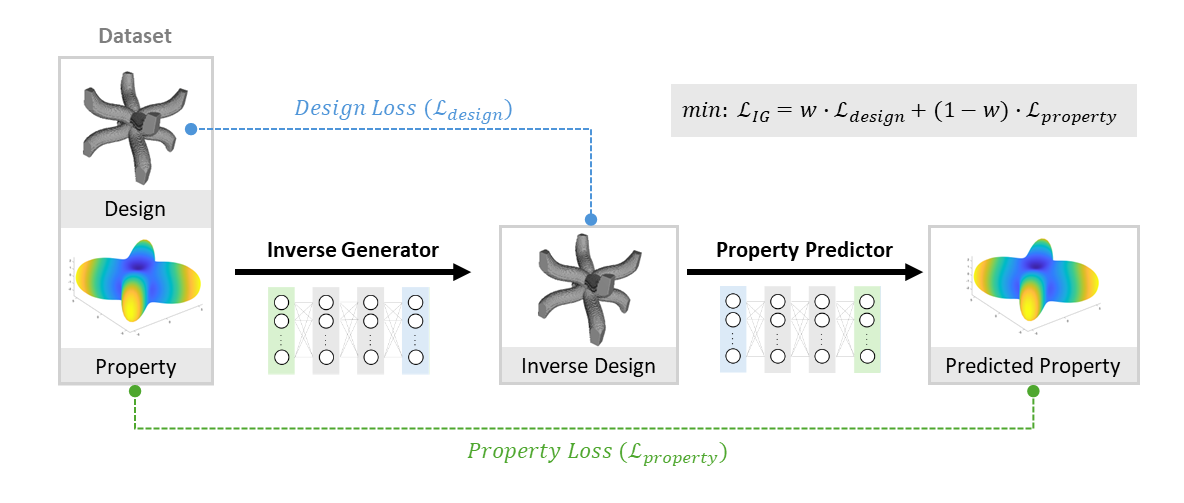

### Import library

Run the cell below to import necessarry python libraries for this tutorial.

In [2]:
# --- Clone repository from Git
!git clone https://github.com/IDEA-lab-IC/Tutorials.git
%cd Tutorials

# --- Standard library
import time
import math
import random

# --- Core scientific stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- PyTorch
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

# --- Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# --- Load predefined functions
from MLPpackage import *
from MLPextention import *

fatal: destination path 'Tutorials' already exists and is not an empty directory.


c:\Users\aw820\Documents\Tutorials\notebooks\Tutorials


-----------

# **1) Create the Property Predictor**

<h4><font color="lightblue">Load dataset and prepare dataset</font></h3>

In [3]:
# --- Load the dataset as numpy array
data  = np.load("dataset_2D_BCC_1000.npz")
prop  = data["prop"]    # input features
param = data["param"]   # target outputs

# --- Determine dimensions
N, prop_dim  = prop.shape
_, param_dim = param.shape

# --- Split dataset
param_train, param_val, param_test, prop_train, prop_val, prop_test = split_prop_param(
    param, prop, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15, print_summary=False)

# --- Scale dataset
param_train, param_val, param_test, prop_train, prop_val, prop_test, param_scaler, prop_scaler = scale_datasets(
    param_train, param_val, param_test, prop_train, prop_val, prop_test,
    scale_inputs=True, scale_outputs=True, feature_range=(-1, 1), print_summary=False)

# --- Convert to Torch tensors
Param_train, Prop_train, Param_val, Prop_val, Param_test, Prop_test = map(
    lambda a: torch.from_numpy(a).float(),
    (param_train, prop_train, param_val, prop_val, param_test, prop_test))

<h4><font color="lightblue">Create DataLoaders</font></h3>

In [4]:
BATCH_SIZE = 256 # number of samples per mini-batch

train_loader = DataLoader(TensorDataset(Param_train, Prop_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TensorDataset(Param_val,   Prop_val),   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(TensorDataset(Param_test,  Prop_test),  batch_size=BATCH_SIZE, shuffle=False)

#### Define a Property Predictor model and train the model

In this section, an MLP-based property predictor is defined and trained to learn the forward mapping from metamaterial unit cell parameters to their corresponding effective properties. The trained model takes cell parameters as input and outputs the predicted material properties, serving as a forward physical surrogate for subsequent inverse design.

In [5]:
HIDDEN  = (8,)    # change as needed
DROPOUT = 0.0

# Create the model
Prop_pred = MLP(in_dim=param_dim, hidden=HIDDEN, out_dim=prop_dim, dropout=DROPOUT)

# Parameter counter
def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

# Print model summary
print(Prop_pred)
print(f"Trainable parameters: {count_params(Prop_pred):,}")

MLP(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=7, bias=True)
  )
)
Trainable parameters: 103


In [6]:
Prop_pred, train_losses, val_losses = train_model(
    Prop_pred,
    train_loader,
    val_loader,
    epochs=300, # training epoch
    patience=20, # early stopping if no validation improvement
    criterion=nn.MSELoss(), # Mean Squared Error (MSE) loss for regression
    optimizer=torch.optim.AdamW(Prop_pred.parameters(), lr=1e-3, weight_decay=1e-4), # Adam optimizer – efficient and commonly used
)

=== Training started ===
Epoch   1/300 | Train: 0.374733 | Val: 0.373427
Epoch  20/300 | Train: 0.175377 | Val: 0.178570
Epoch  40/300 | Train: 0.066572 | Val: 0.068043
Epoch  60/300 | Train: 0.038220 | Val: 0.038868
Epoch  80/300 | Train: 0.021486 | Val: 0.022672
Epoch 100/300 | Train: 0.010943 | Val: 0.012078
Epoch 120/300 | Train: 0.007614 | Val: 0.008324
Epoch 140/300 | Train: 0.006029 | Val: 0.006470
Epoch 160/300 | Train: 0.004942 | Val: 0.005226
Epoch 180/300 | Train: 0.004134 | Val: 0.004320
Epoch 200/300 | Train: 0.003513 | Val: 0.003635
Epoch 220/300 | Train: 0.003026 | Val: 0.003120
Epoch 240/300 | Train: 0.002624 | Val: 0.002668
Epoch 260/300 | Train: 0.002291 | Val: 0.002317
Epoch 280/300 | Train: 0.002022 | Val: 0.002040
Epoch 300/300 | Train: 0.001802 | Val: 0.001801
=== Training complete ===


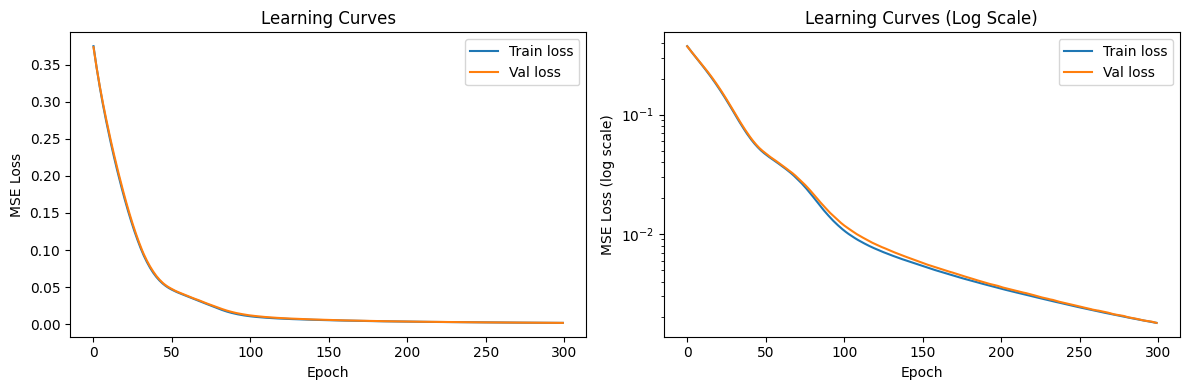

In [7]:
plot_learning_curves(train_losses, val_losses, metric_name="MSE Loss")

#### Test Property Predictor

Test the tained Property Predictor by comparing the predicted properties with the ground truth property values.

In [8]:
prop_true_plot, prop_pred_plot, mae, rmse, r2 = evaluate_model(
    Prop_pred,
    test_loader,
    out_dim=prop_dim,
    out_scaler=prop_scaler,
    scale_outputs=True, # if output is scaled in preprocessing, 'True' is to inverst scale, and compute y in original scale.
    print_summary=True,
)

=== Test Metrics per Output ===
Output 0: MAE=0.003857, RMSE=0.005185, R^2=0.9946
Output 1: MAE=0.005065, RMSE=0.006703, R^2=0.9849
Output 2: MAE=0.003390, RMSE=0.004382, R^2=0.9818
Output 3: MAE=0.004742, RMSE=0.006651, R^2=0.9911
Output 4: MAE=0.003627, RMSE=0.004822, R^2=0.9779
Output 5: MAE=0.002184, RMSE=0.002833, R^2=0.9956
Output 6: MAE=0.011329, RMSE=0.014647, R^2=0.9895

Overall MAE:  0.004885
Overall RMSE: 0.006460
Mean R^2:     0.9879


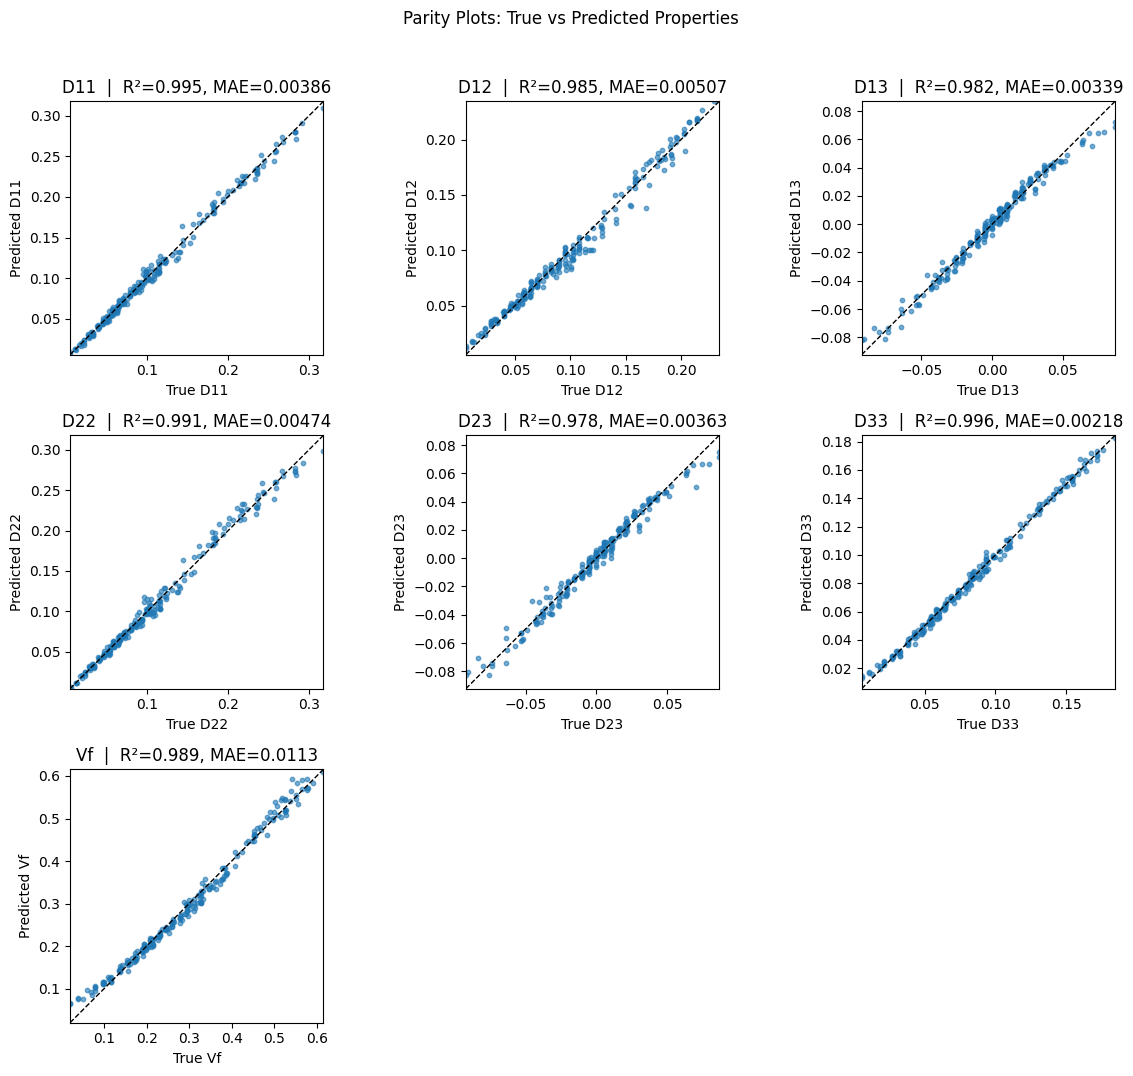

In [9]:
prop_names = ["D11","D12","D13","D22","D23","D33","Vf"]
plot_property_parity_plots(
    prop_true=prop_true_plot,
    prop_pred=prop_pred_plot,
    mae=mae,
    r2=r2,
    out_dim=prop_dim,
    prop_names=prop_names
)

You should achieve a high accuracy with the trained Property Predictor.

# **2) Build and train the inverse generator considering property consistency**

#### Define a Inverse Generator model

Similar as previous tutorials, we initialise a MLP model as Inverse Generator.

In [10]:
INV_HIDDEN  = (16, 8)   # change as needed
INV_DROPOUT = 0.0

# Inverse model: input = 7D property → output = 4D param
Inverse_gen = MLP(
    in_dim=prop_dim,     # 7
    hidden=INV_HIDDEN,
    out_dim=param_dim,   # 4
    dropout=INV_DROPOUT
)

# Freeze Prop_pred (pretrained already, not to be trained here)
Prop_pred.eval()
for p in Prop_pred.parameters():
    p.requires_grad = False

# Count parameters
def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

print(Inverse_gen)
print(f"Trainable parameters (Inverse_gen): {count_params(Inverse_gen):,}")

MLP(
  (net): Sequential(
    (0): Linear(in_features=7, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=4, bias=True)
  )
)
Trainable parameters (Inverse_gen): 300


#### <span style="color:lightblue;">Create DataLoaders</span>

In [11]:
BATCH_SIZE_INV = 256

# We only need prop as the supervised target for the consistency loss
inv_train_loader = DataLoader(TensorDataset(Prop_train), batch_size=BATCH_SIZE_INV, shuffle=True)
inv_val_loader   = DataLoader(TensorDataset(Prop_val),   batch_size=BATCH_SIZE_INV, shuffle=False)
inv_test_loader  = DataLoader(TensorDataset(Prop_test),  batch_size=BATCH_SIZE_INV, shuffle=False)

#### New Loss Function

Different from the previous tutorials, the loss function here is defined based on the discrepancy between the property predicted from the parameters generated by the inverse generator and the target property.

In [12]:
criterion_prop = nn.MSELoss()
optimizer_inv  = torch.optim.Adam(Inverse_gen.parameters(), lr=1e-3, weight_decay=1e-5)

EPOCHS_INV, PATIENCE_INV = 150, 20
train_losses_inv, val_losses_inv = [], []
best_val_inv, best_state_inv, wait = float("inf"), None, 0
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=== Training Inverse_gen with property-consistency loss ===")
for ep in range(1, EPOCHS_INV + 1):
    # ----- Train -----
    Inverse_gen.train()
    total = 0.0
    for (prop_batch,) in inv_train_loader:
        prop_batch = prop_batch.to(device)

        # Predict parameters from properties
        param_hat = Inverse_gen(prop_batch)                     # shape (B,4)

        # Predict properties from predicted parameters using frozen Prop_pred
        prop_hat  = Prop_pred(param_hat)                             # shape (B,7)

        # Consistency loss: predicted props vs input target props
        loss = criterion_prop(prop_hat, prop_batch)

        optimizer_inv.zero_grad()
        loss.backward()
        optimizer_inv.step()

        total += loss.item() * prop_batch.size(0)
    tr_loss = total / len(inv_train_loader.dataset)

    # ----- Validate -----
    Inverse_gen.eval()
    total = 0.0
    with torch.no_grad():  # no grad for evaluation
        for (prop_batch,) in inv_val_loader:
            prop_batch = prop_batch.to(device)
            param_hat  = Inverse_gen(prop_batch)
            prop_hat   = Prop_pred(param_hat)
            loss       = criterion_prop(prop_hat, prop_batch)
            total += loss.item() * prop_batch.size(0)
    va_loss = total / len(inv_val_loader.dataset)

    train_losses_inv.append(tr_loss)
    val_losses_inv.append(va_loss)
    if ep % max(1, EPOCHS_INV // 10) == 0 or ep == 1:
        print(f"Epoch {ep:3d}/{EPOCHS_INV} | Train {tr_loss:.6f} | Val {va_loss:.6f}")

    # Early stopping on validation loss
    if va_loss < best_val_inv - 1e-9:
        best_val_inv, best_state_inv, wait = va_loss, {k: v.detach().cpu().clone() for k, v in Inverse_gen.state_dict().items()}, 0
    else:
        wait += 1
        if wait >= PATIENCE_INV:
            print(f"Early stopping at epoch {ep} (best val={best_val_inv:.6f})")
            break

# Restore best weights
if best_state_inv is not None:
    Inverse_gen.load_state_dict(best_state_inv)
print("=== Inverse_gen training complete ===")


=== Training Inverse_gen with property-consistency loss ===
Epoch   1/150 | Train 0.203737 | Val 0.214091
Epoch  15/150 | Train 0.142941 | Val 0.148115
Epoch  30/150 | Train 0.061863 | Val 0.067928
Epoch  45/150 | Train 0.043096 | Val 0.047329
Epoch  60/150 | Train 0.026465 | Val 0.029658
Epoch  75/150 | Train 0.011970 | Val 0.013625
Epoch  90/150 | Train 0.003613 | Val 0.003782
Epoch 105/150 | Train 0.002155 | Val 0.002214
Epoch 120/150 | Train 0.001588 | Val 0.001671
Epoch 135/150 | Train 0.001326 | Val 0.001405
Epoch 150/150 | Train 0.001160 | Val 0.001226
=== Inverse_gen training complete ===


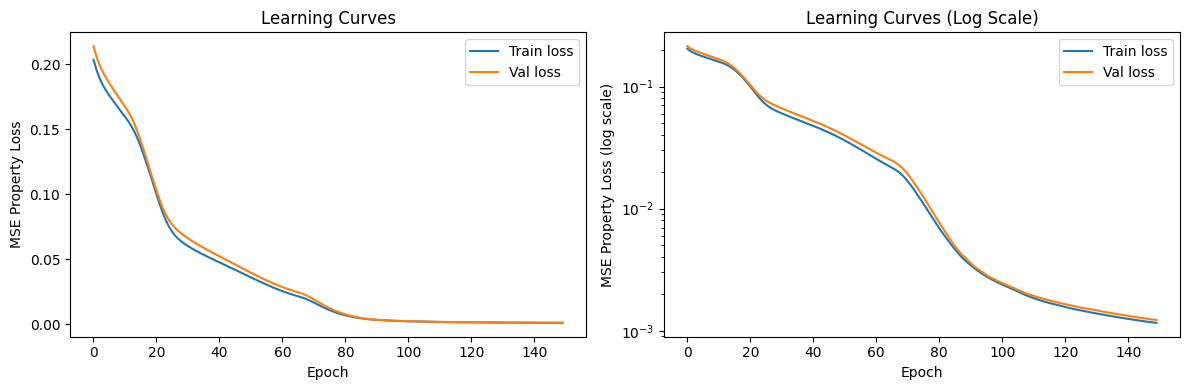

In [13]:
plot_learning_curves(train_losses_inv, val_losses_inv, metric_name="MSE Property Loss")

#### Test Trained Inverse Generator

Predicted property:

$$
\hat{p} = \mathrm{Prop_pred}(\mathrm{Inverse_gen}(\mathrm{prop}))
$$

Ground-truth property:

$$
p = \mathrm{prop}
$$


The accuracy of the inverse generator is evaluated by comparing the predicted cell properties with the target properties.

To illustrate that the generated cell is not necessarily identical to the dataset cell associated with the input target properties, the error in the generated cell parameters is also reported. Despite the low parameter reconstruction similarity, high accuracy in the obtained properties can still be achieved.

In [15]:
metrics = evaluate_inverse_mapping(
    Inversegen=Inverse_gen,
    Proppred=Prop_pred,
    inv_test_loader=inv_test_loader,
    device=device,
    Param_test=Param_test,
    print_report=True
)

=== Test property consistency (per output) ===
d1: MAE=0.026494  RMSE=0.034180  R^2=0.9936
d2: MAE=0.024112  RMSE=0.047052  R^2=0.9900
d3: MAE=0.024401  RMSE=0.037722  R^2=0.9864
d4: MAE=0.015551  RMSE=0.021775  R^2=0.9974
d5: MAE=0.024638  RMSE=0.035016  R^2=0.9883
d6: MAE=0.019015  RMSE=0.025783  R^2=0.9969
d7: MAE=0.028383  RMSE=0.041425  R^2=0.9922
Overall  MAE=0.023228  RMSE=0.034708  Mean R^2=0.9921

=== Test parameter error (per output, sanity check) ===
r1: MAE=0.154091  RMSE=0.214007  R^2=0.8349
r2: MAE=0.075356  RMSE=0.096169  R^2=0.9691
r3: MAE=0.122780  RMSE=0.146795  R^2=0.9223
r4: MAE=0.109056  RMSE=0.139204  R^2=0.9351
Overall  MAE=0.115321  RMSE=0.149044  Mean R^2=0.9153


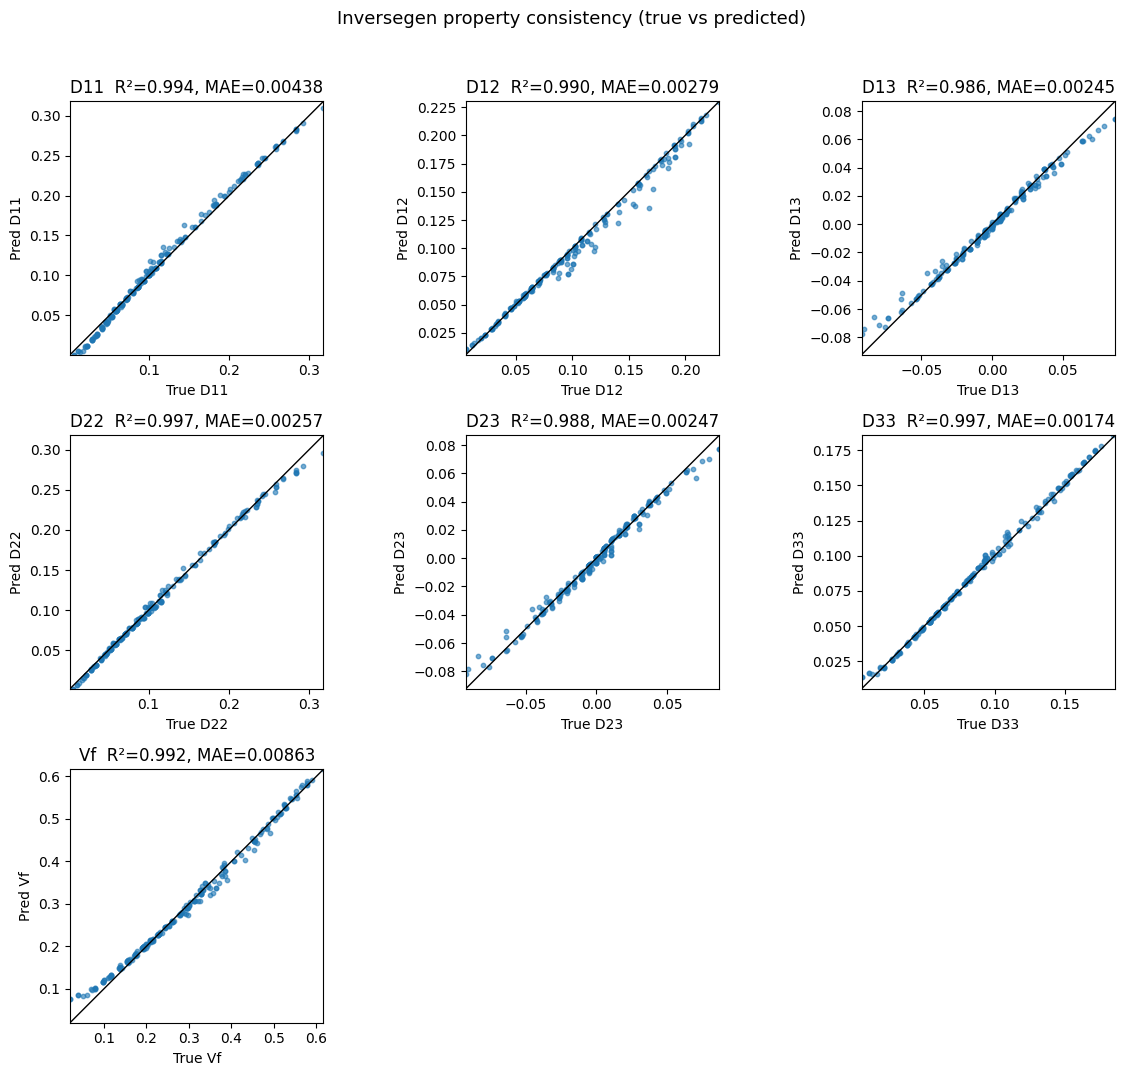

In [17]:
results = plot_inverse_property_consistency(
    Inversegen=Inverse_gen,
    Proppred=Prop_pred,
    inv_test_loader=inv_test_loader,
    device=device,
    scaler_out=prop_scaler,
    scale_outputs=True,
    prop_names=["D11","D12","D13","D22","D23","D33","Vf"]
)

It can be observed that the predicted properties of the obtained cells show high agreement with the target properties.